In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your saved JSON final scores
with open("chefar_score.json", "r") as f:
    saved_data = json.load(f)

# 2. Select 16 layers to plot (e.g., evenly spaced from layer 0 to 23)
# If your model only has 16 layers total, you can just use: layer_indices = range(16)
total_layersAvailable = len(saved_data)
layer_indices = np.linspace(0, total_layersAvailable - 1, 16, dtype=int)

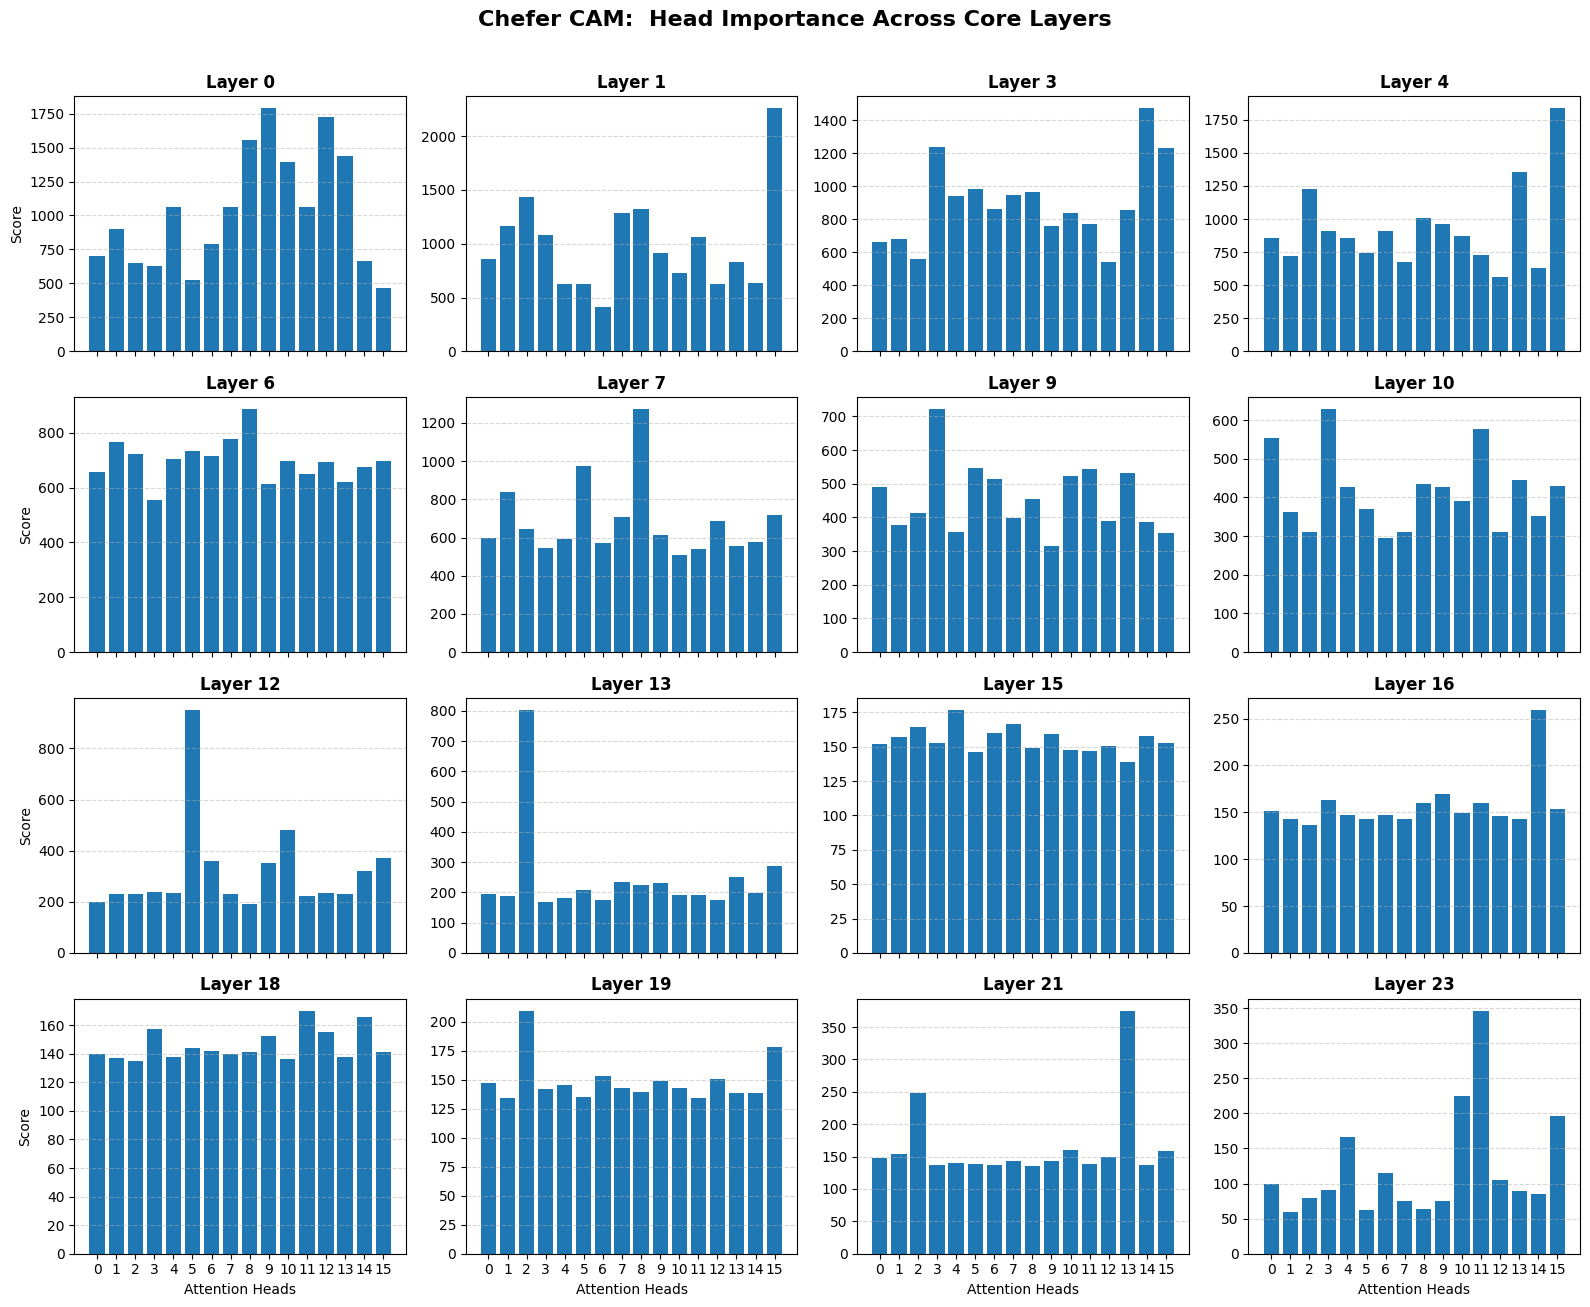

In [24]:


# 3. Initialize a 4x4 plotting grid
fig, axes = plt.subplots(4, 4, figsize=(16, 14), sharex=True)
axes = axes.flatten()  # Flatten into a 1D array of 16 spaces for easy looping

# 4. Generate each plot sequentially
for plot_idx, layer_num in enumerate(layer_indices):
    ax = axes[plot_idx]
    
    # Grab the 16 head scores for this specific layer
    # Data is converted back to numpy array for clean plotting mechanics
    scores = np.array(saved_data[str(layer_num)])
    
    # Create a bar chart for the 16 heads
    head_numbers = np.arange(16)
    bars = ax.bar(head_numbers, scores)
    
    # Formatting details for a professional look
    ax.set_title(f"Layer {layer_num}", fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, 16, 1))  # Show ticks for every second head to avoid overlap
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add a clean label to the outer edges only to keep the grid immaculate
    if plot_idx % 4 == 0:
        ax.set_ylabel("Score")
    if plot_idx >= 12:
        ax.set_xlabel("Attention Heads")

# 5. Global figure adjustments
plt.suptitle("Chefer CAM:  Head Importance Across Core Layers", fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the plot for your research paper figures folder
plt.savefig("chefer_cam_score.png", dpi=300)
plt.show()

True

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()
import wandb
wandb_key=os.getenv("WANDB_KEY")

wandb.login(wandb_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/jovyan/.netrc


True